In [1]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [3]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [4]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

--2026-04-27 20:56:57--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz’

mito.npz            100%[===================>]  35.87M   103MB/s    in 0.3s    

2026-04-27 20:56:59 (103 MB/s) - ‘mito.npz’ saved [37610178/37610178]



In [5]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [6]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [8]:
# TODO: What does the above code do?
# TODO: First line normalizes the image pixel values to be within the interval [0, 1] using min-max normalization.
#       The second line binarizes the segmentation masks by converting to bool then back to float.

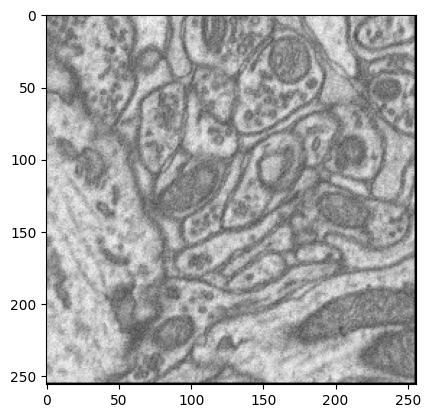

In [9]:
imshow(images[0], cmap='gray')

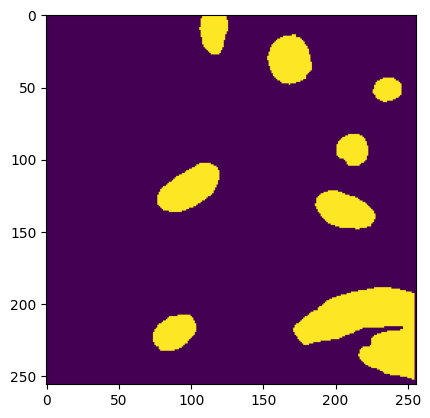

In [10]:
imshow(masks[0])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [12]:
# TODO: What does the above code do?
# TODO: The above code makes training, testing, and validation splits of the data. Training set makes up 70% of the data,
#       testing 15%, and validation 15%.

## 2. Make the Data Pytorch-ready! (10 points)

In [13]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [14]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [15]:
# TODO: What does the above code do?
# TODO: The above code composes together a sequence of image transforms to apply to the data.
#       Transformations are defined only for training data, the transform variable for validation
#       data is left empty. For training data, images have a random horizontal and vertical flip
#       transformation applied, and then a rotation transformation, each occuring with a probability of 0.5.
#       Such transformations are applied to training data only in order to improve the robustness of the model
#       against structure-preserving augmentations. Validation set is left untransformed in order to reduce distribution
#       shift between training data and inference data.

In [16]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [17]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [23]:
# TODO: What does the above code do?
# TODO: The above code wraps our split training/testing/validation data in Dataset objects that have
#       the necessary methods implemented to work with the Pytorch DataLoader objects. Those dataset
#       instances are then passed to DataLoader constructor which handles the batching during training,
#       random shuffling of data, and sets the number of parallel workers to use for these processes.
#       Inference data (validation and test) does not shuffle the data to ensure consistent evaluation.

## 3. Configure the Classifier! (30 points)

In [24]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [25]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [26]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [27]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [28]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.4402, train_dice=0.6401 | val_loss=0.4327, val_dice=0.5296
Epoch 2/10 | train_loss=0.1912, train_dice=0.8444 | val_loss=0.1449, val_dice=0.8663
Epoch 3/10 | train_loss=0.1174, train_dice=0.8697 | val_loss=0.1535, val_dice=0.8016
Epoch 4/10 | train_loss=0.0895, train_dice=0.8912 | val_loss=0.0781, val_dice=0.9073
Epoch 5/10 | train_loss=0.0709, train_dice=0.9116 | val_loss=0.0901, val_dice=0.8821
Epoch 6/10 | train_loss=0.0632, train_dice=0.9213 | val_loss=0.0660, val_dice=0.9143
Epoch 7/10 | train_loss=0.0571, train_dice=0.9264 | val_loss=0.0527, val_dice=0.9340
Epoch 8/10 | train_loss=0.0535, train_dice=0.9294 | val_loss=0.0451, val_dice=0.9444
Epoch 9/10 | train_loss=0.0453, train_dice=0.9410 | val_loss=0.0447, val_dice=0.9383
Epoch 10/10 | train_loss=0.0418, train_dice=0.9460 | val_loss=0.0406, val_dice=0.9484
Best val dice: 0.9484049422400338


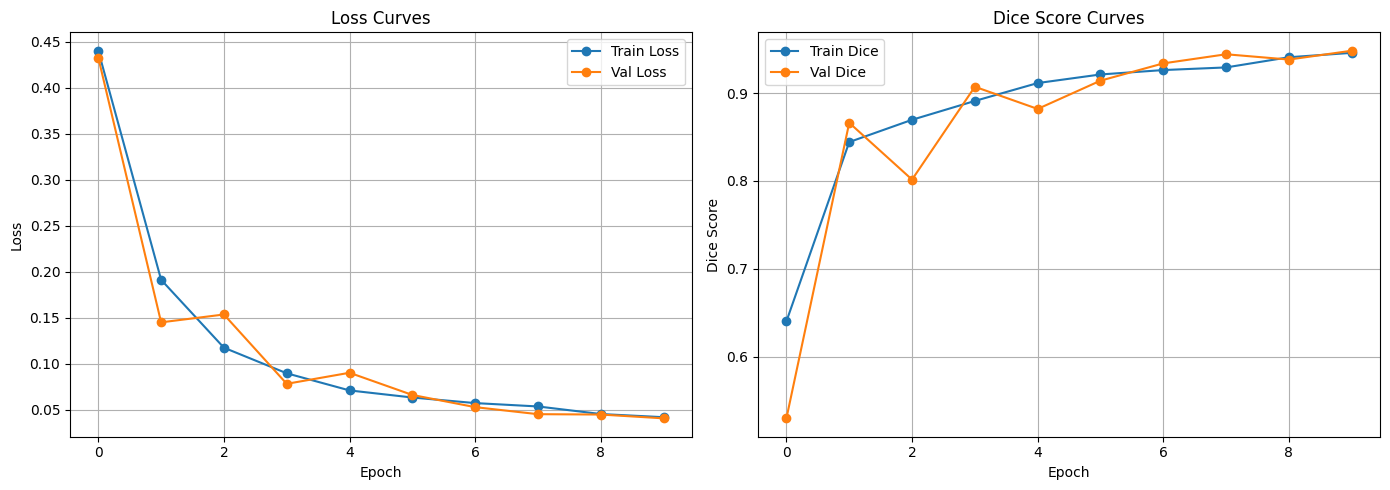

In [29]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='o')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Dice curves
axes[1].plot(train_dices, label='Train Dice', marker='o')
axes[1].plot(val_dices, label='Val Dice', marker='o')
axes[1].set_title('Dice Score Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [30]:
# TODO: Do these plots look good?
# TODO: The plots do look good, as they demonstrate optimal convergence.
#       In the loss curve plots we see that training and validation loss steadily decrease and stay near each other,
#       which shows that the training procedure is working according to the most general tests.
#       The dice score are also good because both train and validation increase and converge at a high value.
#       Since train and validation scores are near each other in both the dice score and loss curves, we can
#       also conclude that overfitting is avoided.

## 5. Testing the U-Net. (20 points)

In [31]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0408
Test dice: 0.9483


In [32]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

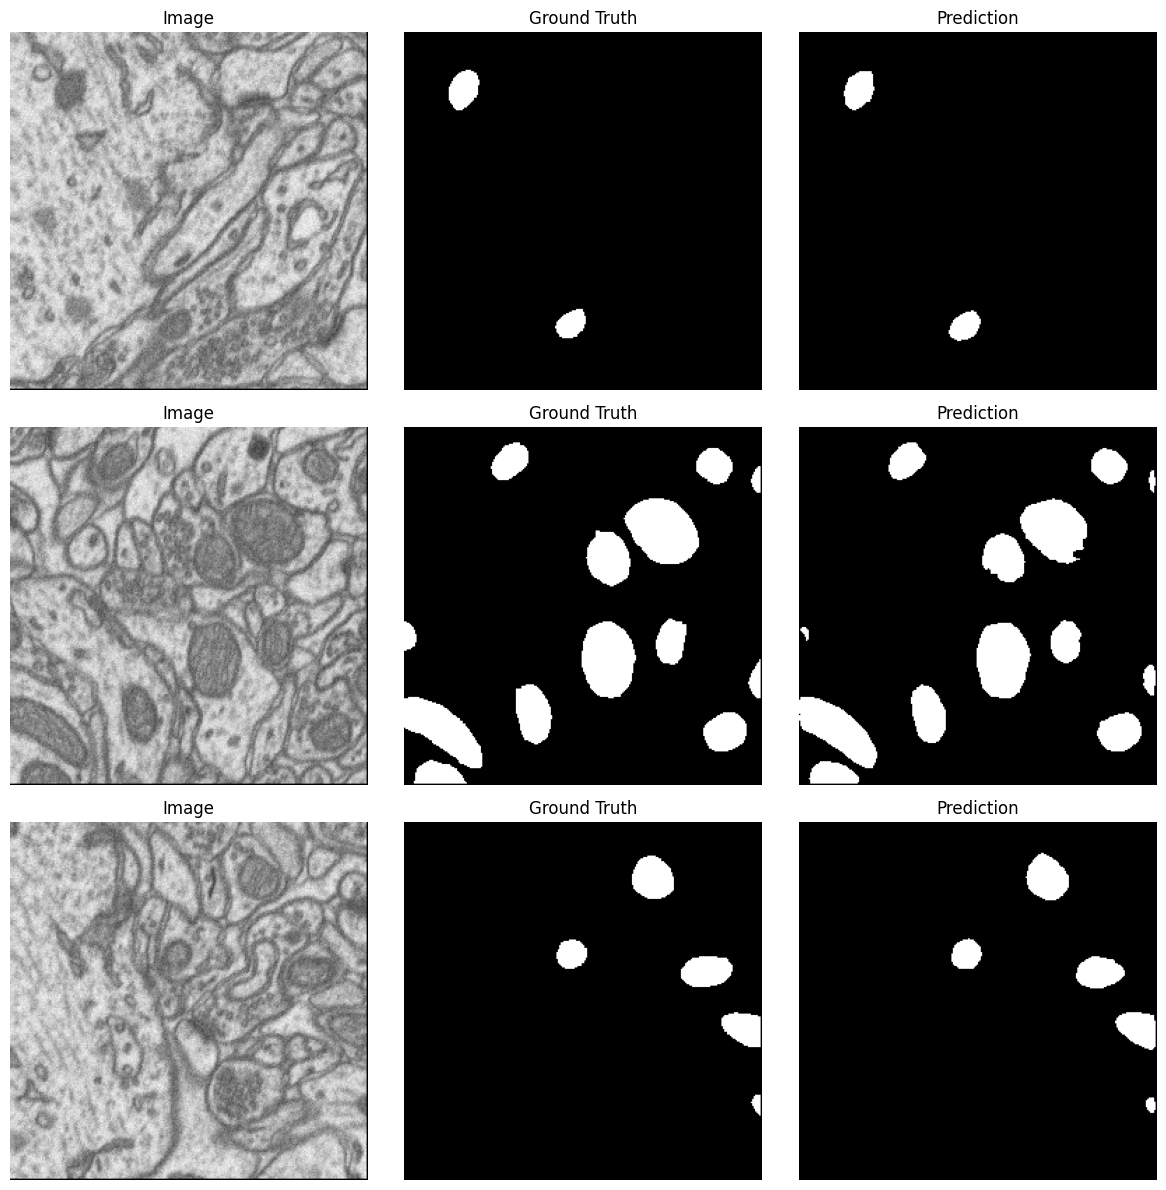

In [33]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [34]:
# TODO: Do you think the classifier works well?
# TODO: Since the test loss is low and test dice score is high, I DO think that our classifier is working well.
#       The model retains an accurate general shape and location of mitochondria, and predicted masks closely align with ground
#       truth annotations. Upon closer visual inspection we can see that edges of the mitochondria appear somewhat distorted, but
#       this is not uncommon in binary segmentation tasks.

## Bonus: Improve the results. (33 points)

Epoch 1/15 | train_loss=0.2057, train_dice=0.6580 | val_loss=0.1278, val_dice=0.7380
Epoch 2/15 | train_loss=0.0640, train_dice=0.8550 | val_loss=0.0453, val_dice=0.9024
Epoch 3/15 | train_loss=0.0427, train_dice=0.8951 | val_loss=0.0407, val_dice=0.9013
Epoch 4/15 | train_loss=0.0343, train_dice=0.9132 | val_loss=0.0323, val_dice=0.9213
Epoch 5/15 | train_loss=0.0297, train_dice=0.9222 | val_loss=0.0315, val_dice=0.9193
Epoch 6/15 | train_loss=0.0269, train_dice=0.9308 | val_loss=0.0225, val_dice=0.9429
Epoch 7/15 | train_loss=0.0271, train_dice=0.9267 | val_loss=0.0244, val_dice=0.9384
Epoch 8/15 | train_loss=0.0238, train_dice=0.9368 | val_loss=0.0218, val_dice=0.9427
Epoch 9/15 | train_loss=0.0207, train_dice=0.9447 | val_loss=0.0184, val_dice=0.9533
Epoch 10/15 | train_loss=0.0192, train_dice=0.9475 | val_loss=0.0194, val_dice=0.9494
Epoch 11/15 | train_loss=0.0178, train_dice=0.9531 | val_loss=0.0171, val_dice=0.9562
Epoch 12/15 | train_loss=0.0174, train_dice=0.9532 | val_loss=0

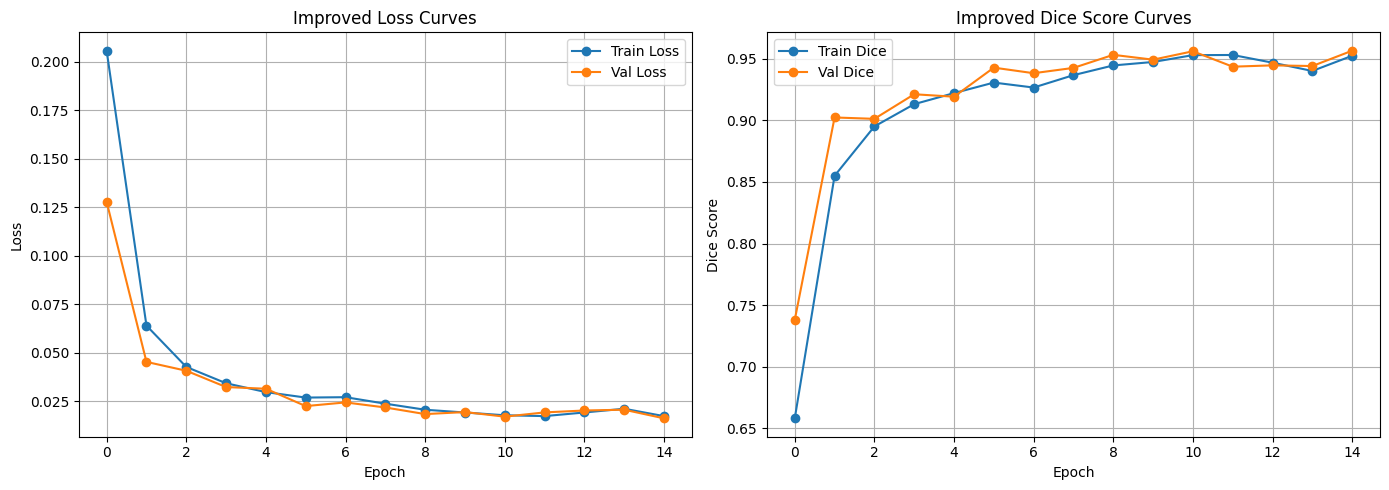

In [38]:
# Try to get better performance and show an improved Dice score on the test set!
# TODO: YOUR CODE!
# BONUS: Improved U-Net with better encoder and augmentation

import segmentation_models_pytorch as smp
import albumentations as A

# 1. STRONGER AUGMENTATION
train_transform_improved = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

# 2. DATASETS AND LOADERS
train_dataset_improved = MitoDataset(X_train, y_train, transform=train_transform_improved)
val_dataset_improved = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset_improved = MitoDataset(X_test, y_test, transform=val_transform)

train_loader_improved = DataLoader(train_dataset_improved, batch_size=16, shuffle=True, num_workers=2)
val_loader_improved = DataLoader(val_dataset_improved, batch_size=16, shuffle=False, num_workers=2)
test_loader_improved = DataLoader(test_dataset_improved, batch_size=16, shuffle=False, num_workers=2)

# 3. BETTER ENCODER (ResNet34 instead of default)
model_improved = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
).to(device)

# 4. SAME LOSS AND OPTIMIZER AS BEFORE
loss_fn = nn.BCEWithLogitsLoss()
optimizer_improved = torch.optim.Adam(model_improved.parameters(), lr=1e-3)

# 5. TRAIN
num_epochs_improved = 15

train_losses_imp, val_losses_imp = [], []
train_dices_imp, val_dices_imp = [], []
best_val_dice_imp = 0.0

for epoch in range(num_epochs_improved):
    train_loss, train_dice = run_epoch(model_improved, train_loader_improved, optimizer=optimizer_improved)
    val_loss, val_dice = run_epoch(model_improved, val_loader_improved, optimizer=None)

    train_losses_imp.append(train_loss)
    val_losses_imp.append(val_loss)
    train_dices_imp.append(train_dice)
    val_dices_imp.append(val_dice)

    if val_dice > best_val_dice_imp:
        best_val_dice_imp = val_dice
        torch.save(model_improved.state_dict(), "best_mito_model_improved.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs_improved} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice (improved):", best_val_dice_imp)

# 6. EVALUATE ON TEST SET
model_improved.load_state_dict(torch.load("best_mito_model_improved.pth", map_location=device))
test_loss_imp, test_dice_imp = run_epoch(model_improved, test_loader_improved, optimizer=None)

print("Improved Test Loss:", round(test_loss_imp, 4))
print("Improved Test Dice:", round(test_dice_imp, 4))

# 7. PLOT CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses_imp, label='Train Loss', marker='o')
axes[0].plot(val_losses_imp, label='Val Loss', marker='o')
axes[0].set_title('Improved Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_dices_imp, label='Train Dice', marker='o')
axes[1].plot(val_dices_imp, label='Val Dice', marker='o')
axes[1].set_title('Improved Dice Score Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#